In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [3]:
news = pd.read_csv('../data/raw/raw_analyst_ratings.csv', index_col=0, parse_dates=['date'])
print("Shape:", news.shape)
news.head(2)

Shape: (1407328, 5)


,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A


In [4]:
news['date'] = pd.to_datetime(news['date'], errors='coerce')
news = news.dropna(subset=['date'])
news['headline_len'] = news['headline'].str.len()
news['headline_len'].describe()


count    55987.000000
mean        80.015254
std         56.126094
min         12.000000
25%         42.000000
50%         63.000000
75%         91.000000
max        512.000000
Name: headline_len, dtype: float64

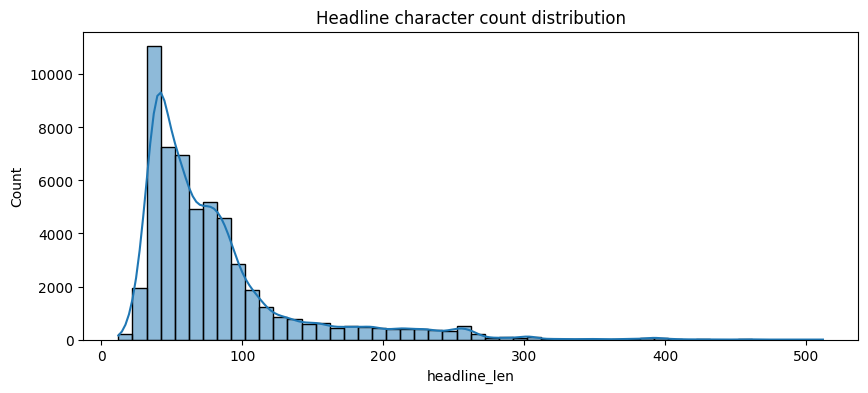

In [5]:
plt.figure(figsize=(10,4))
sns.histplot(news['headline_len'], bins=50, kde=True)
plt.title('Headline character count distribution')
plt.show()

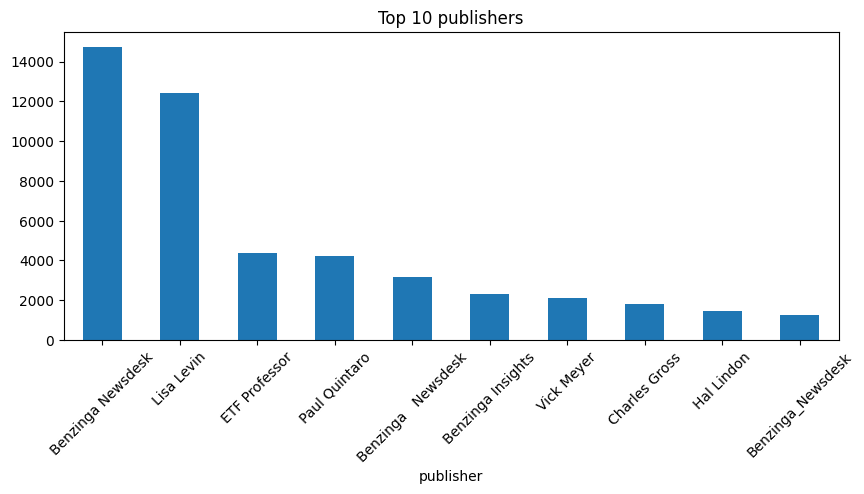

In [6]:
top_pubs = news['publisher'].value_counts().head(10)
top_pubs.plot(kind='bar', figsize=(10,4))
plt.title('Top 10 publishers')
plt.xticks(rotation=45)
plt.show()

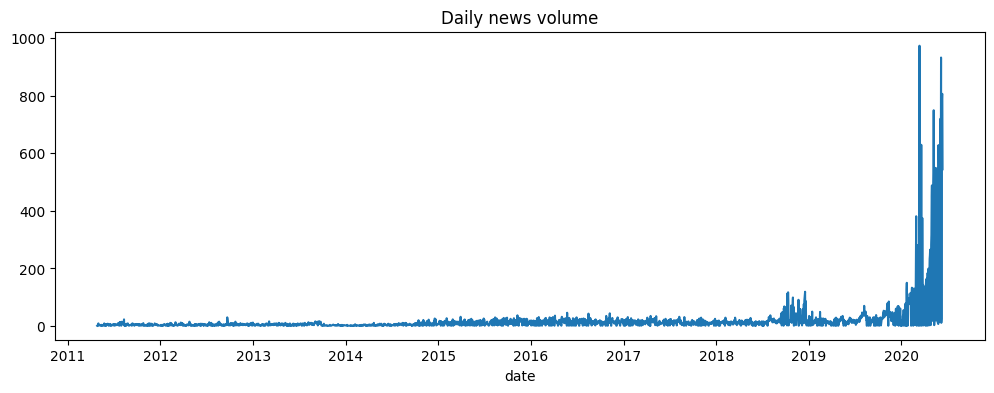

In [7]:
daily_counts = news.groupby(news['date'].dt.date).size()
daily_counts.plot(figsize=(12,4), title='Daily news volume')
plt.show()